In [1]:
import numpy as np

In [2]:
f = [2,3,5,1,4,6,3,2,5]
g = [1/3,1/3,1/3]
print(f)
print(g)

[2, 3, 5, 1, 4, 6, 3, 2, 5]
[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]


In [3]:
# 离散序列得卷积运算
print(np.convolve(f,g,mode='valid'))

[3.33333333 3.         3.33333333 3.66666667 4.33333333 3.66666667
 3.33333333]


卷积层得定义和应用测试

In [4]:
import torch
import matplotlib.pyplot as plt

In [5]:
# 1. 读取图片
img = plt.imread('../data/duck.jpg')
print(img.shape)

(1080, 1080, 3)


In [7]:
# 2. 将图片数据调整为卷积层输入特征图对应得形状
input = torch.tensor(img).permute(2,0,1).float()
print('输入特征图得形状：',input.shape)

输入特征图得形状： torch.Size([3, 1080, 1080])


In [8]:
# 3. 定义卷积层
conv = torch.nn.Conv2d(in_channels=3,out_channels=3,kernel_size=9,stride=3,padding=0,bias=False)

In [9]:
# 4. 向前传播，将卷积层应用到输入特征图上
output = conv(input)
print('输出特征图得形状：',output.shape)

输出特征图得形状： torch.Size([3, 358, 358])


In [21]:
# 5. 将输出特征图转换为图片数据
output = torch.from_numpy(output)
output = torch.clamp(output.int(),0,255)
output = output.permute(1,2,0).detach().numpy()
print(output.shape)

(358, 358, 3)


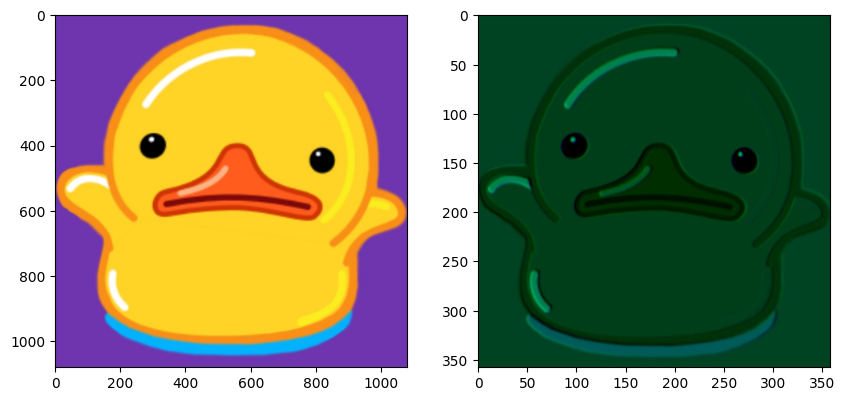

In [22]:
# 显示图片，进行对比
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img)
ax[1].imshow(output)
plt.show()